In [2]:
import numpy as np
import matplotlib.pyplot as plt

### Definicija sistema

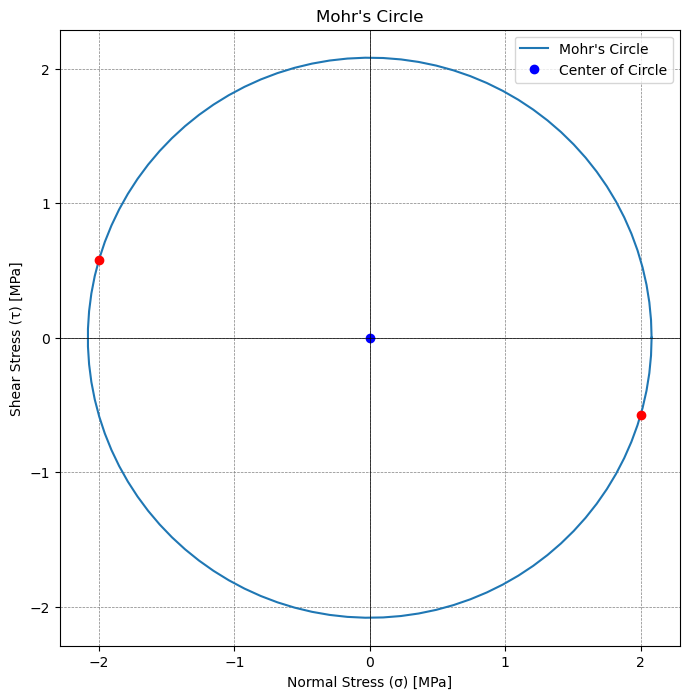

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Given values
sigma_x = 2  # MPa
sigma_y = -2  # MPa
sigma_xy = -np.sqrt(3)/3 # MPa

# Calculate center and radius
sigma_avg = (sigma_x + sigma_y) / 2
R = np.sqrt(((sigma_x - sigma_y) / 2)**2 + sigma_xy**2)

# Create the circle
theta = np.linspace(0, 2 * np.pi, 100)
sigma_circle = sigma_avg + R * np.cos(theta)
tau_circle = R * np.sin(theta)

# Plot the circle
plt.figure(figsize=(8, 8))
plt.plot(sigma_circle, tau_circle, label='Mohr\'s Circle')
plt.plot([sigma_x, sigma_y], [sigma_xy, -sigma_xy], 'ro')  # Stress points
plt.plot(sigma_avg, 0, 'bo', label='Center of Circle')

# Adding labels and grid
plt.xlabel('Normal Stress (σ) [MPa]')
plt.ylabel('Shear Stress (τ) [MPa]')
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5)
plt.legend()
plt.title('Mohr\'s Circle')

# Display the plot
plt.show()


In [3]:
# mass 
m1 = 1
m2 = 1
m3 = 1
m4 = 1
m5 = 1


masses = np.array([m1, m2, m3, m4, m5])
M = np.diag(masses)

c1 = 11
c2 = 12
c3 = 13
c4 = 14
c5 = 15
c6 = 16

damping = np.array([c1, c2, c3, c4, c5, c6])

C = np.diag(damping[:-1]) + np.diag(damping[1:])

for i in np.arange(len(damping)-2):
    C[i, i+1] = -damping[i+1]
    C[i+1, i] = -damping[i+1]

k1 = 110
k2 = 120
k3 = 130
k4 = 140
k5 = 150
k6 = 160

stiffnes = np.array([k1, k2, k3, k4, k5, k6])

K = np.diag(stiffnes[:-1]) + np.diag(stiffnes[1:])
# K = np.zeros((len(stiffnes)-1, len(stiffnes)-1))
for i in np.arange(len(stiffnes)-2):
    K[i, i+1] = -stiffnes[i+1]
    K[i+1, i] = -stiffnes[i+1]

print(M)
print("-----------------")
print(C)
print("-----------------")
print(K)

[[1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 0 0 1 0]
 [0 0 0 0 1]]
-----------------
[[ 23 -12   0   0   0]
 [-12  25 -13   0   0]
 [  0 -13  27 -14   0]
 [  0   0 -14  29 -15]
 [  0   0   0 -15  31]]
-----------------
[[ 230 -120    0    0    0]
 [-120  250 -130    0    0]
 [   0 -130  270 -140    0]
 [   0    0 -140  290 -150]
 [   0    0    0 -150  310]]


### Nedušen sistem

In [5]:
A = np.linalg.inv(M)@K
eigval, eigvec = np.linalg.eig(A)
print(eigval)
# eigvec shape
x = 

[ 35.69163956 133.22474019 266.06005056 516.05774292 398.96582677]
(5, 5)


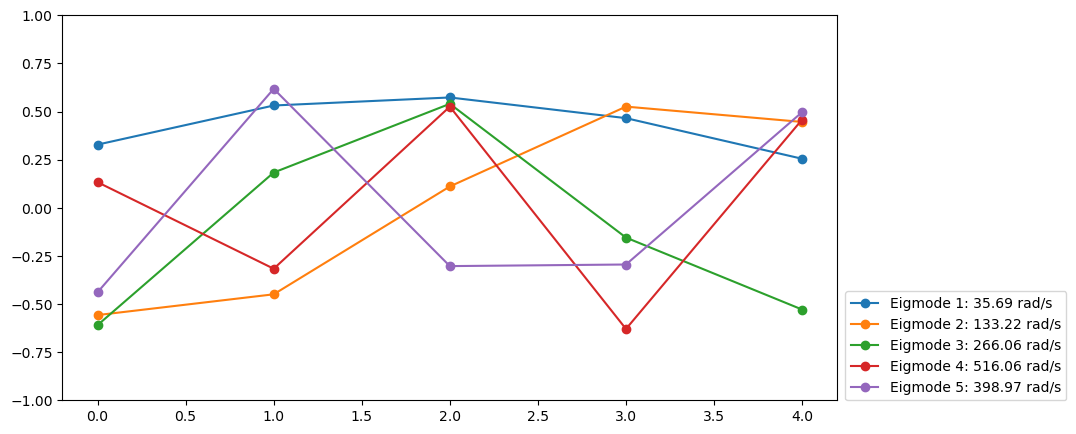

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
for i in np.arange(len(eigvec)):
    ax.plot(eigvec[:,i], 'o-', label=f'Eigmode {i+1}: {eigval[i]:.2f} rad/s');
ax.set_ylim(-1, 1)
ax.legend(loc=(1.01, 0));

### Prehod v odzivni model

In [ ]:
# Fourierjeva analiza x
X = np.fft.fft(x)

[0.         0.06288438 0.12570658 0.18840447 0.25091606 0.31317953
 0.37513331 0.43671613 0.49786711 0.55852577]


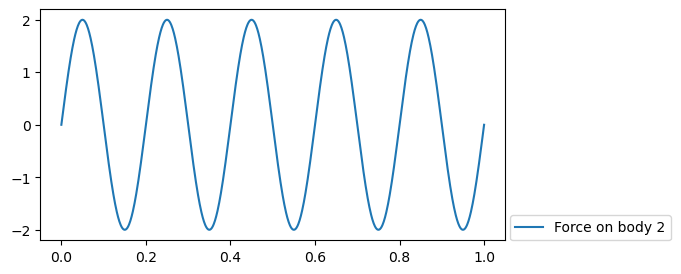

In [ ]:
# definicija harmonskega vzbujanja: na telesu 2 
omega = 5
t = np.linspace(0, 1, 1000)

force = np.array([0, 2, 0, 0, 0, 0])

f = np.zeros((len(force), len(t)))
np.shape(f)

for i in np.arange(len(t)):
    f[:, i] = force[:] * np.sin(2*np.pi*omega*t[i])
print(f[1, :10])

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(t, f[1, :], label=f'Force on body 2')
ax.legend(loc=(1.01, 0));

C:\Users\marko\AppData\Local\Temp\ipykernel_14244\3001334416.py:13: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show();


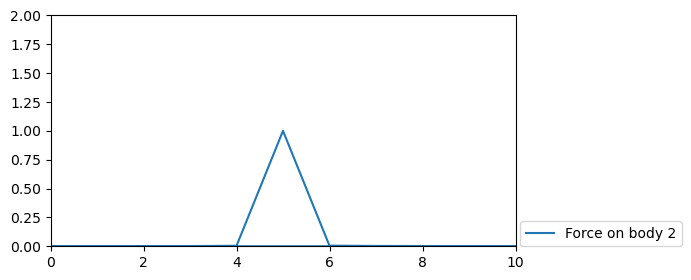

In [ ]:
# Fourierjeva transformacije

F = np.fft.fft(f, norm='forward')
# F[1:] *= 2
dt = t[1] - t[0]
freq = np.fft.fftfreq(len(t), dt)
# plot
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(freq, np.abs(F[1, :]), label=f'Force on body 2')
ax.legend(loc=(1.01, 0));
ax.set_xlim(0, 10)
ax.set_ylim(0, 2)
fig.show();

ValueError: x and y must have same first dimension, but have shapes (1000,) and (6, 1000)

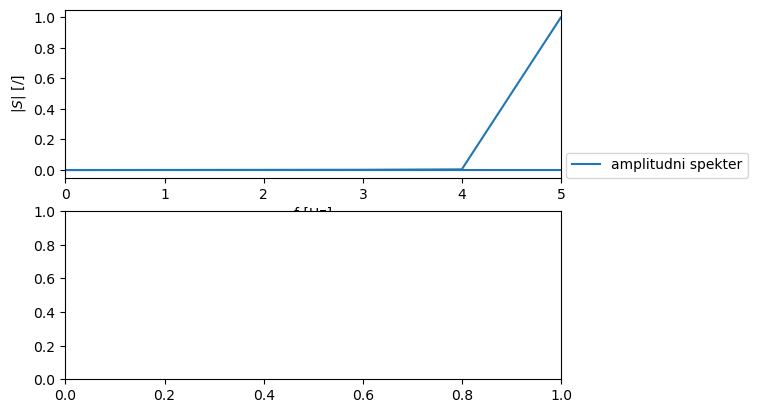

In [ ]:
fig, ax = plt.subplots(2, 1)
ax[0].plot(freq, np.abs(F[1, :]), 'C0', label='amplitudni spekter')
ax[0].set_xlim(0, 5)
ax[0].set_xlabel('f [Hz]')
ax[0].set_ylabel('$|S|$ [/]')
# ax[0].axvline(f1, c='k', lw=0.5)
# ax[0].axvline(f2, c='k', lw=0.5)
# ax[0].axhline(A1, c='k', lw=0.5)
# ax[0].axhline(A2, c='k', lw=0.5)
ax[0].legend(loc=(1.01, 0))

ax[1].plot(freq, np.angle(F), 'C1', label='fazni spekter')
ax[1].set_xlim(0, 5)
ax[1].set_xlabel('f [Hz]')
ax[1].set_ylabel('$\\angle S$ [rad]')
# ax[1].axvline(f1, c='k', lw=0.5)
# ax[1].axvline(f2, c='k', lw=0.5)
# ax[1].axhline(phi1, c='k', lw=0.5)
# ax[1].axhline(phi2, c='k', lw=0.5)
ax[1].legend(loc=(1.01, 0));